# Stylometry and authorship attribution

The goal of this lab activity is to experiment with techniques for measuring stylistic similarity among texts, such as to identify the author of an unknown text. There are three parts to the lab. In the first, part we throw several known tools (from NLTK and scikit-learn) at a collection of texts to see what they reveal; in the second part, we observe the use of Burrow's delta implemented from scratch; in the third part, you can experiment with the stylo package.

First, let's import everything we'll need.


In [ ]:
# For reading in files and doing word counts
import nltk
from nltk.corpus import PlaintextCorpusReader
from nltk import FreqDist

# For doing counts ourselves
from collections import Counter

# For standard machine learning tools
from sklearn.feature_extraction.text import CountVectorizer  
from sklearn.decomposition import PCA
from sklearn.naive_bayes import MultinomialNB  
from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

# For tabular displays
import pandas as pd

# For visual (graphical) displays
import matplotlib.pyplot as plt
%matplotlib inline

# For arrays
import numpy as np

## 1. Looking at the data and applying standard ML tools

First let's have a look at some data. It's worth asking whether or not such a thing as a *stylome* exists, that is, does an author have a distinctive style that is quantifiable, stable over time, and usable for identifying an author. In this first part of the lab, we'll see evidence of the existence of stylomes and see just how easy authoriship attribution can be under ideal conditions.

### Alcott vs Ingalls Wilder

Our first data set is a comparison study between two American authors:
Louisa May Alcott, who published books in the late 1800s, most famously *Little Women*; and Laura Ingalls Wilder, who published books in the *Little House* series in the 1930s and 1940s, based on her childhood experiences in the late 1800s. Although they are both American women, they represent starkly different regional and educational backgrounds (Transcendentalist New England vs pioneer west), and were about one generation apart. Let's examine their stylistic differences.

Five identified texts by each author plus two additional unidentified texts can be found in `/homes/tvandrun/Public/cs384/stylo/alcottwilder1/corpus`. (By *unidentified* I don't mean that these texts actually have unknown authorship, just that we're treating them as unknown. I know who wrote them, and it won't be too hard for you to figure it out either.) Use NLTK to read in these texts and make word counts.

In [3]:
aw_folder1 = PlaintextCorpusReader('/homes/tvandrun/Public/cs384/stylo/alcottwilder1/corpus', '.*\\.txt')
aw_texts = {x:[y.lower() for y in nltk.Text(aw_folder1.words(x)) if y.isalpha()] for x in aw_folder1.fileids()}
aw_text_names = list(aw_texts.keys())
aw_fds = {x:FreqDist(aw_texts[x]) for x in aw_texts}

Make sure you understand what all these variables are standing for. `aw_text_names` is the names of the files, and `aw_texts` is a dictionary associating the file names with tokenized versions of their contents.

In [4]:
aw_text_names

['alcott_eightcousins.txt',
 'alcott_littlemen.txt',
 'alcott_littlewomenpt1.txt',
 'alcott_littlewomenpt2.txt',
 'alcott_oldfashionedgirl.txt',
 'wilder_farmerboy.txt',
 'wilder_longwinter.txt',
 'wilder_plumcreek.txt',
 'wilder_prairie.txt',
 'wilder_silverlake.txt',
 'xxx.txt',
 'yyy.txt']

In [5]:
aw_texts['xxx.txt'][:10]

['chapter',
 'coming',
 'home',
 'three',
 'young',
 'men',
 'stood',
 'together',
 'on',
 'a']

In [7]:
aw_texts

{'alcott_eightcousins.txt': ['chapter',
  'two',
  'girls',
  'rose',
  'sat',
  'all',
  'alone',
  'in',
  'the',
  'big',
  'best',
  'parlor',
  'with',
  'her',
  'little',
  'handkerchief',
  'laid',
  'ready',
  'to',
  'catch',
  'the',
  'first',
  'tear',
  'for',
  'she',
  'was',
  'thinking',
  'of',
  'her',
  'troubles',
  'and',
  'a',
  'shower',
  'was',
  'expected',
  'she',
  'had',
  'retired',
  'to',
  'this',
  'room',
  'as',
  'a',
  'good',
  'place',
  'in',
  'which',
  'to',
  'be',
  'miserable',
  'for',
  'it',
  'was',
  'dark',
  'and',
  'still',
  'full',
  'of',
  'ancient',
  'furniture',
  'sombre',
  'curtains',
  'and',
  'hung',
  'all',
  'around',
  'with',
  'portraits',
  'of',
  'solemn',
  'old',
  'gentlemen',
  'in',
  'wigs',
  'severe',
  'nosed',
  'ladies',
  'in',
  'top',
  'heavy',
  'caps',
  'and',
  'staring',
  'children',
  'in',
  'little',
  'bob',
  'tailed',
  'coats',
  'or',
  'short',
  'waisted',
  'frocks',
  'it'

The texts are of comparable length (between about 50000 and 100000 tokens). The book *Little Women* has two parts, which, for the sake of length, are treated as separate texts.

In [8]:
for x in aw_text_names :
    print(x + ': ' + str(len(aw_texts[x])))

alcott_eightcousins.txt: 74737
alcott_littlemen.txt: 107366
alcott_littlewomenpt1.txt: 90572
alcott_littlewomenpt2.txt: 100337
alcott_oldfashionedgirl.txt: 105443
wilder_farmerboy.txt: 58762
wilder_longwinter.txt: 69663
wilder_plumcreek.txt: 56705
wilder_prairie.txt: 53156
wilder_silverlake.txt: 58969
xxx.txt: 96134
yyy.txt: 63123


### Word usage

To find evidence of stylomes for these two authors, we want to analyze them by their most common words. To find a set of iteresting words, we combine the texts together and find the frequency distribution of the words overall in the corpus.

In [9]:
aw_combined = []
for x in aw_text_names :
    aw_combined.extend(aw_texts[x])
aw_combined_fd = FreqDist(aw_combined)
sorted_word_list = sorted(list(set(aw_combined)), key=lambda x: aw_combined_fd[x], reverse=True)


Let's take a look at them. There won't be many surprises.

In [11]:
sorted_word_list[:15]

['the',
 'and',
 'to',
 'a',
 'of',
 'i',
 'it',
 'was',
 'in',
 'her',
 'she',
 'he',
 'you',
 'that',
 'for']

###To see the relative frequency of these common words across the two authors and the various texts, we display the word use rates in a table. To make the table pretty, we use a `DataFrame` from the pandas library, which contains data structures for tabular data. Notice that the table entries are not raw word counts, since those would vary with the length of the text. Instead, they are word use *rates*, which we caluclated by dividing the word count by the length of the text (number of tokens).###

In [20]:
pd.DataFrame(index=aw_text_names, columns=sorted_word_list[:15], 
             data = [[aw_fds[text][w]/len(aw_texts[text]) for w in sorted_word_list[:15]] 
                     for text in aw_text_names])

,the,and,to,a,of,i,it,was,in,her,she,he,you,that,for
alcott_eightcousins.txt,0.041358,0.039137,0.026747,0.026292,0.018719,0.021087,0.014023,0.011092,0.013380,0.015347,0.012778,0.007573,0.013902,0.011534,0.010985
alcott_littlemen.txt,0.044772,0.044902,0.026330,0.023005,0.018032,0.017287,0.013962,0.012043,0.013990,0.008029,0.006278,0.013701,0.010767,0.009985,0.010422
alcott_littlewomenpt1.txt,0.038445,0.043435,0.025770,0.022822,0.016672,0.021949,0.013426,0.010301,0.012366,0.018604,0.012730,0.007729,0.012841,0.008314,0.010500
alcott_littlewomenpt2.txt,0.040085,0.041351,0.027268,0.023959,0.018856,0.020082,0.015378,0.010963,0.013205,0.015558,0.011860,0.008920,0.012099,0.011651,0.012518
alcott_oldfashionedgirl.txt,0.035119,0.039234,0.026318,0.023899,0.017204,0.021120,0.015297,0.011798,0.011874,0.016549,0.013201,0.008706,0.012765,0.011750,0.011950
wilder_farmerboy.txt,0.070794,0.051955,0.021272,0.016831,0.016609,0.003982,0.014414,0.016456,0.012253,0.002570,0.003744,0.025765,0.006007,0.007760,0.003965
wilder_longwinter.txt,0.066535,0.039232,0.022896,0.016393,0.015805,0.010924,0.016034,0.015661,0.014111,0.006603,0.010953,0.013436,0.007522,0.010809,0.005412
wilder_plumcreek.txt,0.062552,0.051054,0.019328,0.015413,0.013879,0.008183,0.013808,0.018887,0.012574,0.011798,0.015466,0.008306,0.006507,0.009206,0.003862
wilder_prairie.txt,0.068647,0.050361,0.019490,0.016254,0.015426,0.006114,0.012981,0.017571,0.014392,0.007751,0.011701,0.017872,0.004609,0.010084,0.003367
wilder_silverlake.txt,0.065289,0.045007,0.020451,0.017908,0.014770,0.009547,0.013397,0.014397,0.014770,0.008191,0.012413,0.009174,0.007563,0.009123,0.005562


Take some time inspecting this table---you may be overwhelmed with data at first, but on careful examination some patterns emerge. How do these authors differ from each other (but are consistent within their own works) in the usage rate of some of these words? And what evidence do those usage rates give for the authorship of the unidentified texts?

### POS usage

In class I have suggested that part-of-speech rate could be a distinguishing factor in an author's style. We can test that. Let's use NLTK's tagger to find the parts of speech for all the tokens. (This may take a minute or two.)

In [21]:
aw_tagged = {x:nltk.pos_tag(aw_texts[x], tagset='universal') for x in aw_text_names}

This is a dictionary associating text names with POS-tagged versions of those texts. Do you know what that looks like? Check it out:

In [25]:
aw_tagged['xxx.txt'][:5]

[('chapter', 'NOUN'),
 ('coming', 'VERB'),
 ('home', 'ADV'),
 ('three', 'NUM'),
 ('young', 'ADJ')]

Now, let's count the frequencies of each POS tag.

In [15]:
aw_tag_counts = {x:Counter([p[1] for p in aw_tagged[x]]) for x in aw_text_names}
tagset = ['VERB', 'NOUN', 'PRON', 'ADJ', 'ADV', 'ADP', 
          'CONJ', 'DET', 'NUM', 'PRT', 'X', '.']

And then display POS usage rates, just like we did for the common word types.

In [26]:
pd.DataFrame(index=aw_text_names, columns=tagset, 
             data = [[aw_tag_counts[text][t]/len(aw_texts[text]) for t in tagset] for text in aw_text_names])

,VERB,NOUN,PRON,ADJ,ADV,ADP,CONJ,DET,NUM,PRT,X,.
alcott_eightcousins.txt,0.231465,0.203795,0.103362,0.091427,0.070166,0.115886,0.047473,0.096619,0.005031,0.034548,0.000214,0.000013
alcott_littlemen.txt,0.222519,0.211994,0.102826,0.090802,0.068728,0.111525,0.053509,0.096632,0.006455,0.034694,0.000317,0.000000
alcott_littlewomenpt1.txt,0.231032,0.212891,0.107219,0.094698,0.068741,0.107704,0.052765,0.086969,0.004946,0.032582,0.000453,0.000000
alcott_littlewomenpt2.txt,0.216431,0.209574,0.107009,0.094721,0.070702,0.116896,0.052583,0.092957,0.005382,0.033368,0.000379,0.000000
alcott_oldfashionedgirl.txt,0.231433,0.195603,0.107243,0.095511,0.082831,0.111567,0.049278,0.087526,0.005434,0.033260,0.000313,0.000000
wilder_farmerboy.txt,0.215939,0.239168,0.098329,0.077482,0.062574,0.096882,0.059579,0.110565,0.007284,0.031789,0.000408,0.000000
wilder_longwinter.txt,0.232232,0.226476,0.096048,0.080258,0.067209,0.102278,0.047098,0.110403,0.004866,0.032715,0.000416,0.000000
wilder_plumcreek.txt,0.227158,0.233683,0.096746,0.084455,0.065162,0.096605,0.058090,0.102972,0.004867,0.029433,0.000811,0.000018
wilder_prairie.txt,0.219542,0.233407,0.095756,0.078937,0.069776,0.099086,0.058883,0.110693,0.004967,0.028557,0.000395,0.000000
wilder_silverlake.txt,0.224304,0.233682,0.090234,0.082993,0.069664,0.102325,0.051281,0.110414,0.005223,0.029151,0.000712,0.000017


Are the POS rates consistent for an author across different works? Are they different between authors?

### Standard ML tools

Now let's see how well the standard techniques of machine learning can classify texts. As mentioned in class, this is different from our activity classifying reviews and articles in last week's lab in that we have a much smaller number of texts (although the texts themselves are much bigger).

First we need to make vectors out of the texts, for which we use `CountVectorizer`. We'll use the 100 most common word types. Make sure you can explain the dimensions of the resulting matrix.

In [27]:
folder = '/homes/tvandrun/Public/cs384/stylo/alcottwilder1/corpus'
vec = CountVectorizer(input='filename', max_features=100)
vec.fit([folder + '/' + f for f in aw_text_names])
aw_vectors = vec.transform([folder + '/' + f for f in aw_text_names]).toarray()
aw_vectors.shape

(12, 100)

Let's see what these vectors look like. First, project them into 2 dimensions using principal component analysis. 

In [29]:
projected = PCA(n_components=2).fit_transform(aw_vectors)
projected.shape

(12, 2)

Now let's put those reduced vectors on a scatter plot. Recall that principal component analysis can thought of using this analogy: the points exist in a higher-dimensional space (in this case, 100 dimensions), but we can find the shadows they would cast onto a two-dimensional surface. 

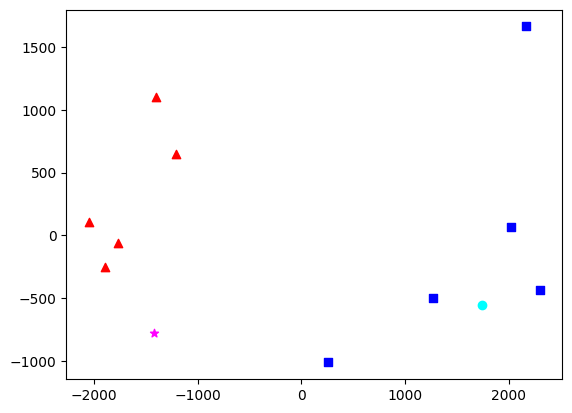

In [31]:
plt.scatter(projected[0:5, 0], projected[0:5, 1], c = 'blue', marker = 's') # Alcott: Blue squares
plt.scatter(projected[5:10,0], projected[5:10, 1], c = 'red', marker = '^') # Wilder: Red triangles
plt.scatter(projected[10,0], projected[10,1], c = 'cyan', marker = 'o') # xxx.txt: Cyan circle
plt.scatter(projected[11,0], projected[11,1], c = 'magenta', marker = '*') # yy.txt: Magenta star
plt.show()

Hopefully this now provides conclusive evidence that stylometric analsyis---in fact, as simple of an analysis as word counts---can be used to distinguish between authors and to classify the two unidentified texts.

Take a moment to make sure that you and your partner understand all the steps from text files to dots-in-two-dimensions. What do these dots mean? My intention is that you understand how this all works and that you're not treating it as something magical. You might not understand the mathematical details of principal component analsyis (although some of you should), but you can think about that step in terms of the analogy mentioned above. If you need help putting this all together, let me know.

Now that we see how distinct these texts are when treated as word-count vectors, classification should be a cinch. In fact, any off-the-shelf classifier from scikit-learn will get 100%.

In [32]:
model = MultinomialNB()
model.fit(aw_vectors[:10], [0,0,0,0,0,1,1,1,1,1])  # 0 for Alcott, 1 for Wilder
print('Alcott: ' + str(model.predict(aw_vectors[:5])))
print('Wilder: ' + str(model.predict(aw_vectors[5:10])))
print('xxx.txt: ' + str(model.predict(aw_vectors[10].reshape(1, -1))[0]))
print('yyy.txt: ' + str(model.predict(aw_vectors[11].reshape(1, -1))[0]))

Alcott: [0 0 0 0 0]
Wilder: [1 1 1 1 1]
xxx.txt: 0
yyy.txt: 1


In [33]:
model = KNeighborsClassifier()
model.fit(aw_vectors[:10], [0,0,0,0,0,1,1,1,1,1])  
print('Alcott: ' + str(model.predict(aw_vectors[:5])))
print('Wilder: ' + str(model.predict(aw_vectors[5:10])))
print('xxx.txt: ' + str(model.predict(aw_vectors[10].reshape(1, -1))[0]))
print('yyy.txt: ' + str(model.predict(aw_vectors[11].reshape(1, -1))[0]))

Alcott: [0 0 0 0 0]
Wilder: [1 1 1 1 1]
xxx.txt: 0
yyy.txt: 1


In [34]:
model = SVC()
model.fit(aw_vectors[:10], [0,0,0,0,0,1,1,1,1,1])  
print('Alcott: ' + str(model.predict(aw_vectors[:5])))
print('Wilder: ' + str(model.predict(aw_vectors[5:10])))
print('xxx.txt: ' + str(model.predict(aw_vectors[10].reshape(1, -1))[0]))
print('yyy.txt: ' + str(model.predict(aw_vectors[11].reshape(1, -1))[0]))

Alcott: [0 0 0 0 0]
Wilder: [1 1 1 1 1]
xxx.txt: 0
yyy.txt: 1


## 2. Implementing Burrow's Delta

Now let's try a measure specifically designed for authorship attribution.
Burrow's Delta (Proposed by John Burrows in "'Delta': a Measure of Stylistic Difference and a Guide to Likely Authorship", *Computers and the Humanities*, 2003) is used to measure the stylistic similarities between two documents or collections. In this section we'll explore an implementation of Burrow's Delta and test it on 
Alcott vs Wilder, and then also apply it to
the Federalist Papers. This part of today's activity was partially adapted from [Francois Dominic Laramee, "Introduction to Stylometry with Python" on *Programming Historian*](https://programminghistorian.org/en/lessons/introduction-to-stylometry-with-python).



To use Burrow's Delta (or any other stylistic measurement), we need to know what features to look for. As is typical, we represent texts as vectors of counts of the most common words in the entire collection. Accordingly,
we first concatenate all of the individual texts and make a frequency distribution of the entire corpus.

Once features are selected, the delta between two individual texts is the sum of the absolute values of the
differences between the z-scores of the two texts over all the features. You might need to read that last sentence a couple of times, even if you know/remember what a z-score is. A z-score for an event (such as a feature in a data point) is the difference between the value and the mean divided by the standard deviation. 

Let two texts $X$ and $Y$ be represented as feature vectors $\mathbf{x}$ and $\mathbf{y}$ where $x_i$ and $y_i$ are their respective values for feature $i$. Let $\mu_i$ and $\sigma_i$ be the means and standard devation for feature $i$ over the entire collection. Then, the delta between $X$ and $Y$ is

\\[
\begin{array}{rcl}
\Delta_B(\mathbf{x}, \mathbf{y}) &=& \sum_{i=1}^{n} \left| \frac{x_i - \mu_i}{\sigma_i} - \frac{y_i - \mu_i}{s_i}  \right| \\ \\
&=& \sum_{i=1}^n \left| \frac{x_i - y_i}{\sigma_i}  \right|
\end{array}
\\]

Since a lot of information needs to be computed first before the delta between two texts can be computed, we encapsulate all this into the following class. The class's constructor makes all the frequency distributions (redoing some work from above, but now easily applied to other texts), means, standard deviations, and z-scores.
The parameters to the constructor are a dictionary associating text names with the texts themselves (like our `aw_texts`) and the number of features to use (`mfw`, that is, "most frequent words").

In the end, an instance of this class supports a methd that takes two texts by name and returns their delta.

Inspect the code carefully to understand how it works. A prize for any bugs you find. (I don't know of any bugs in this code, but it wouldn't shock me if there are some.)

In [ ]:
import math

class BurrowsDelta() :
    def __init__(self, text_collection, mfw) :
        # Find the number of texts
        num_texts = len(text_collection)

        # Make the frequency distributions for each text
        text_fds = {x:FreqDist(text_collection[x]) for x in text_collection}
        
        # Concatenate the entire corpus
        whole_corpus = []
        for x in text_collection :
            whole_corpus += text_collection[x]

        # Make a frequency distribution for the entire collection
        collection_mffd = nltk.FreqDist(whole_corpus).most_common(mfw)

        # Find the most common words --- those will be our features
        features = [word for (word,count) in collection_mffd]

        
        
        # Make the feature vectors for the texts. The feature values for the texts are normalized
        # counts. Specifically, for each text, for each feature, divide the count
        # for that feature in that text by the length of that text
        feature_vectors = {x:[text_fds[x][features[i]]/len(text_collection[x]) for i in range(mfw)] for x in text_collection}

        # Calculate the means for all those features
        feature_means = [sum([feature_vectors[x][i] for x in text_collection]) / num_texts for i in range(mfw)]

        # Calculate the standard deviations 
        feature_stdevs = [math.sqrt(sum([(feature_vectors[x][i]-feature_means[i])**2 for x in text_collection])/num_texts)
                        for i in range(mfw)]

        # Everything so far is used only temporarily in the constructor. The following three things
        # we'll need to keep.
        
        # Calculate the z scores. Specifically, this is a dictionary from text names to vectors for per-feature
        # z-scores for each text.
        self.zscores = {x:[(feature_vectors[x][i]-feature_means[i])/feature_stdevs[i] for i in range(mfw)]
                       for x in text_collection}

        self.num_features = mfw
        self.num_texts = num_texts
        
    # The delta of two texts in the collection is the sum of their absolute value differences for z scores
    # on all features
    def delta(self, x, y) :
        return sum([abs(self.zscores[x][i] - self.zscores[y][i]) for i in range(self.num_features)])/self.num_features


Let's see how this works. First, let's try it with only the 30 most frequent words. (Come back later and try different numbers of features.)

In [ ]:
aw_bd = BurrowsDelta(aw_texts, 30)

Now observe the deltas between two texts of the same author, two texts of different authors, and the same text.

In [ ]:
aw_bd.delta('alcott_eightcousins.txt', 'alcott_littlemen.txt')

In [ ]:
aw_bd.delta('alcott_eightcousins.txt', 'wilder_farmerboy.txt')

In [ ]:
aw_bd.delta('alcott_eightcousins.txt', 'alcott_eightcousins.txt')

What do these numbers mean? In short, a lower delta means the texts are more similar. But to get a feel for the differences, let's compute deltas between all 12 texts and visualize them as a "heat map."

In [ ]:
delta_matrix = [[aw_bd.delta(x, y) for x in aw_text_names] for y in aw_text_names]

plt.figure(figsize=(15,15))
plt.imshow(delta_matrix)
plt.yticks(range(len(delta_matrix)), aw_text_names)
plt.xticks(range(len(delta_matrix)), aw_text_names, rotation=25)
plt.colorbar()

What does this head-to-head comparison among all the texts tell us?

Now let's try this on the Federalist Papers. There are more texts (85), but they are all much shorter (essay-length rather than book-length).

In [ ]:
fed_folder1 = PlaintextCorpusReader('/homes/tvandrun/Public/cs384/stylo/federalist1/corpus', '.*\\.txt')
fed_texts = {x:[y.lower() for y in nltk.Text(fed_folder1.words(x)) if y.isalpha()] for x in fed_folder1.fileids()}
fed_text_names = fed_texts.keys()
fed_fds = {x:FreqDist(fed_texts[x]) for x in fed_texts}
for x in fed_text_names :
    print(x + ': ' + str(len(fed_texts[x])))

Let's train a Burrow's delta function on this collection and make a heat map of the head-to-head comparisons. As before, we're using 30 features, but you can change that.

In [ ]:
fed_bd = BurrowsDelta(fed_texts, 30)
delta_matrix = [[fed_bd.delta(x, y) for x in fed_text_names] for y in fed_text_names]

plt.figure(figsize=(20,20))
plt.imshow(delta_matrix)
plt.yticks(range(85), fed_text_names)
plt.xticks(range(85), fed_text_names, rotation=25)
plt.colorbar()

To orient yourself as you look at this graph, look particularly at the stripe corresponding to the "Jay" texts. What do the colors indicate? Then see if you can find other stripes that stand out. What do they suggest?

Do pursue this more systematically, lets focus on the disputed texts. Let's collect the text names into categories with the following lists:

In [ ]:
disputed = [x for x in fed_text_names if x[0]=='D']
hamilton = [x for x in fed_text_names if x[0]=='H']
madison = [x for x in fed_text_names if x[0]=='M']
jay = [x for x in fed_text_names if x[0]=='J']

For each disputed text, let's take the average of its delta with all the known texts by each of the authors.

In [ ]:
pd.DataFrame(index=disputed, columns=['Hamilton', 'Madison', 'Jay'],
             data = [[np.mean([fed_bd.delta(text, ham) for ham in hamilton]),
                      np.mean([fed_bd.delta(text, mad) for mad in madison]),
                      np.mean([fed_bd.delta(text, j) for j in jay])
                     ] for text in disputed])

What does this table mean? The first datum (`Disputed_fed18.txt`, `Hamilton`) indicates the average of of the delta between `Disputed_fed18.txt` and each of the known Hamilton texts. What evidence does this give for the authorship of the disputed papers? Here's what the scholarly consensus is (see, for example [this summary from the Library of Congress](https://guides.loc.gov/federalist-essays-in-historic-newspapers/authors)):


- 18-20 were written mainly by Madison, with some help from Hamilton.
- 49 was written by Madison.
- 50-52 were a collaboration between Madison and Hamilton, contributing about equally.
- 53 was written by Madison.
- 53-58 and 63 were a collaboration between Madison and Hamilton, contributing about equally.
- 64 was written by Jay (Hamilton mixed this up with 54).

## Using stylo

Now let's look at the two collections using the stylo package.

In [1]:
import rpy2.robjects as ro

In [2]:
import rpy2.robjects as ro
R = ro.r
R.library("stylo")
# The next line makes your home folder the "working directory" where anything running in
# R will write out results. Change this to another folder if you don't want stuff written in
# your home folder.
R.setwd("~")

R[write to console]: 
### stylo version: 0.7.5 ###

If you plan to cite this software (please do!), use the following reference:
    Eder, M., Rybicki, J. and Kestemont, M. (2016). Stylometry with R:
    a package for computational text analysis. R Journal 8(1): 107-121.
    <https://journal.r-project.org/archive/2016/RJ-2016-007/index.html>

To get full BibTeX entry, type: citation("stylo")



'/homes/lukebilhorn/CSCI384/labs'


The following will run the stylo tool I demo'd in class on Friday. 

In [3]:
# The stuff being passed to stylo is a dictionary, with ** indicating that the dictionary keys
# should be treated as named arguments to the function. The reason for this rigmarole is that
# we need to use the parameter corpus.dir to indicate where the texts are. R allows identifiers to
# have dots in their names (such as 'corpus.dir'), which is not allowed in Python.
R.stylo(**{'corpus.dir':'/homes/tvandrun/Public/cs384/stylo/federalist1/corpus', 'gui':True})

R[write to console]: using current directory...

R[write to console]: Performing no sampling (using entire text as sample)


R[write to console]: slicing input text into tokens...


R[write to console]: 
turning words into features, e.g. char n-grams (if applicable)...

R[write to console]: 

R[write to console]: Total nr. of samples in the corpus: 85

R[write to console]: 

R[write to console]: The corpus consists of 191851 tokens

R[write to console]: 

R[write to console]: processing  85  text samples

R[write to console]: .
R[write to console]: .
R[write to console]: .
R[write to console]: .
R[write to console]: .
R[write to console]: .
R[write to console]: .
R[write to console]: .
R[write to console]: 

R[write to console]: combining frequencies into a table...

R[write to console]: 


R[write to console]: culling @ 0	available features (words) 5000

R[write to console]: Calculating z-scores... 


R[write to console]: Calculating classic Delta distances...

R[write to console]: MF

RRuntimeError: Error in h(simpleError(msg, call)) : 
  error in evaluating the argument 'object' in selecting a method for function 'show': argument is of length zero


<rpy2.robjects.vectors.ListVector object at 0x7f460c311c80> [RTYPES.VECSXP]
R classes: ('stylo.results',)
[FloatSexp..., StrSexpVe..., StrSexpVe..., FloatSexp..., ..., FloatSexp..., FloatSexp..., LangSexpV..., LangSexpV...]
  distance.table: <class 'rpy2.rinterface.FloatSexpVector'>
  <rpy2.rinterface.FloatSexpVector object at 0x7f460c311300> [RTYPES.REALSXP]
  features: <class 'rpy2.rinterface_lib.sexp.StrSexpVector'>
  <rpy2.rinterface_lib.sexp.StrSexpVector object at 0x7f460c311240> [RTYPES.STRSXP]
  features.actually.used: <class 'rpy2.rinterface_lib.sexp.StrSexpVector'>
  <rpy2.rinterface_lib.sexp.StrSexpVector object at 0x7f460c311300> [RTYPES.STRSXP]
  frequencies.0.culling: <class 'rpy2.rinterface.FloatSexpVector'>
  <rpy2.rinterface.FloatSexpVector object at 0x7f460c311240> [RTYPES.REALSXP]
  list.of.edges: <class 'rpy2.rinterface.ListSexpVector'>
  <rpy2.rinterface.ListSexpVector object at 0x7f460c309d40> [RTYPES.VECSXP]
  table.with.all.freqs: <class 'rpy2.rinterface.FloatSe

In the folder `/homes/tvandrun/Public/cs384/stylo/federalist2` I have reorganized the Federalist papers into a training set of collected known essays by authors (`primary_set/Hamilton.txt` etc) and disputed essays (`secondary_texts/Disputed_fed18.txt` etc). Use the classify tool to attribute authorship to the disputed essays. Note that this will output results to files in the R "working directory" specified earlier. 

In [ ]:
R.classify(**{'training.corpus.dir':'/homes/tvandrun/Public/cs384/stylo/federalist2/primary_set', 'test.corpus.dir':'/homes/tvandrun/Public/cs384/stylo/federalist2/secondary_set','gui':True})

Output can be found in file called `final_results.txt`. Compare this with the scholarly conscensus.

In similar structure, `/homes/tvandrun/Public/cs384/stylo/alcottwilder2` contains collected identified corpora in a subfolder `primary_set` and the unidentified texts in a subfolder `secondary_set`. Use the classify tool to identify the authors of the unidentified texts.

In [ ]:
R.stylo(**{'corpus.dir':'/homes/tvandrun/Public/cs384/stylo/alcottwilder1/corpus', 'gui':True})